### Submission Criteria

Based on the project objectives and the insights gained from the initial analysis, here are the key criteria for your submission:

1.  **Explore Gender vs. Spending Score:** Analyze the relationship between 'Gender' and 'Spending Score (1-100)' to see if gender plays a significant role in spending habits. Visualizations and summary statistics would be helpful here.


,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,112.0,51.53,24.11,5.0,35.0,50.0,73.0,99.0
Male,88.0,48.51,27.90,1.0,24.5,50.0,70.0,97.0


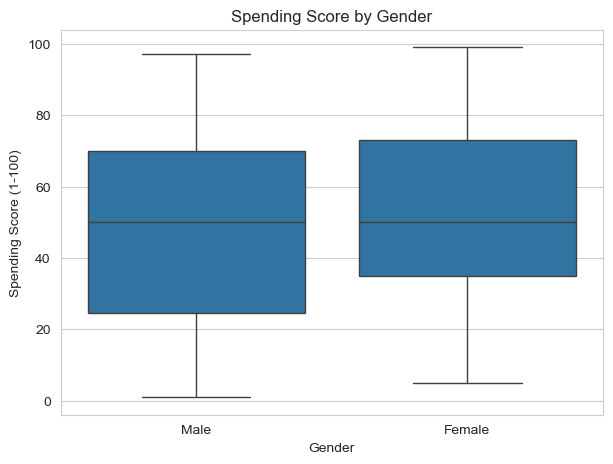

Mean Spending Score by Gender:
 Gender
Female    51.53
Male      48.51
Name: Spending Score (1-100), dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.cluster.hierarchy as sch

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Set plot style
sns.set_style('whitegrid')

# Load the dataset from the user-provided file
df = pd.read_csv("../data/customers.csv")

# 1) Summary statistics by Gender
display(
    df.groupby("Gender")["Spending Score (1-100)"].describe().round(2)
)

# 2) Boxplot
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Gender", y="Spending Score (1-100)")
plt.title("Spending Score by Gender")
plt.xlabel("Gender"); plt.ylabel("Spending Score (1-100)")
plt.show()

# 3) Optional: quick effect-size style view
gender_means = df.groupby("Gender")["Spending Score (1-100)"].mean().round(2)
print("Mean Spending Score by Gender:\n", gender_means)


**Insights :** 
Both genders show similar average spending (~50 points), but females are slightly higher on average and cluster more around moderate-to-high values, whereas males exhibit a broader dispersion including very low spenders.

2.  **Apply Feature Engineering for Clustering:** Create a new feature using existing data (Feature Engineering). Then, explore if clustering can be effectively performed using this newly engineered feature in combination with one or more existing features. Document the feature engineering process, the chosen features for clustering, the determination of the optimal number of clusters (e.g., using the Elbow Method), and the resulting cluster visualization and interpretation.

In [2]:
# 0) Feature engineering
df.info()
eps = 1e-6
den = df["Annual Income (k$)"].replace(0, eps)
df["Spend_to_Income_Ratio"] = df["Spending Score (1-100)"] / den

df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Spend_to_Income_Ratio
0,1,Male,19,15,39,2.600000
1,2,Male,21,15,81,5.400000
2,3,Female,20,16,6,0.375000
3,4,Female,23,16,77,4.812500
4,5,Female,31,17,40,2.352941


In [3]:
# 1) Prepare features
feats = ["Spend_to_Income_Ratio", "Age"]
X_fe = df[feats].copy()

scaler_fe = StandardScaler()
X_fe_scaled = scaler_fe.fit_transform(X_fe)

c:\Anaconda\envs\ai-portfolio\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Anaconda\envs\ai-portfolio\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda\envs\ai-portfolio\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less 

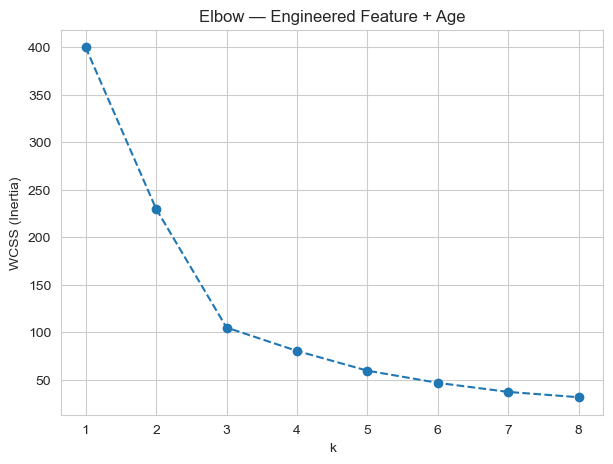

In [4]:
# 2) Elbow method
inertias = []
KMAX = 8
for k in range(1, KMAX+1):
    km = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    km.fit(X_fe_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1, KMAX+1), inertias, marker="o", linestyle="--")
plt.title("Elbow — Engineered Feature + Age")
plt.xlabel("k"); plt.ylabel("WCSS (Inertia)")
plt.xticks(range(1, KMAX+1))
plt.show()

In [5]:
# 3) k  = 4 elbow suggestion
k_best = 4
kmeans_fe = KMeans(n_clusters=k_best, init="k-means++", random_state=42, n_init=10)
df["FE_Cluster"] = kmeans_fe.fit_predict(X_fe_scaled)

c:\Anaconda\envs\ai-portfolio\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


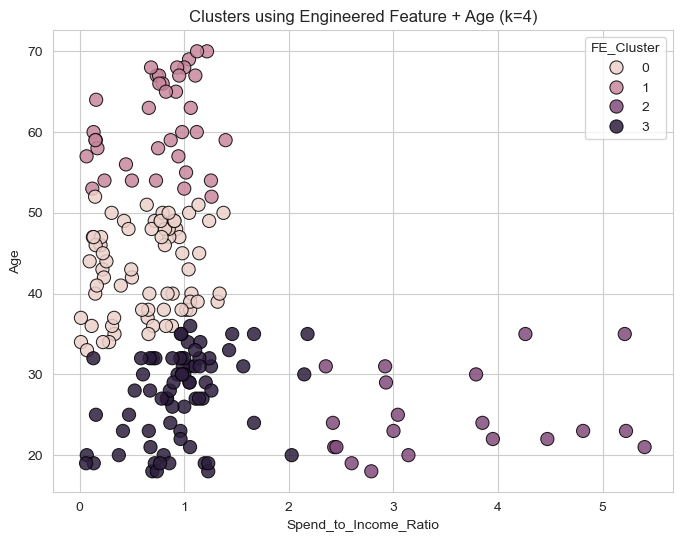

In [6]:
# 4) Visualize clusters
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Spend_to_Income_Ratio", y="Age", hue="FE_Cluster", s=90, edgecolor="black", alpha=0.85)
plt.title(f"Clusters using Engineered Feature + Age (k={k_best})")
plt.show()


In [7]:
# 5) Simple interpretation table
display(
    df.groupby("FE_Cluster")[["Spend_to_Income_Ratio", "Age", "Annual Income (k$)", "Spending Score (1-100)"]]
      .mean().round(2)
)

,Spend_to_Income_Ratio,Age,Annual Income (k$),Spending Score (1-100)
FE_Cluster,,,,
0,0.64,42.94,67.93,39.13
1,0.76,61.19,52.84,37.65
2,3.55,24.85,23.00,77.55
3,0.96,27.44,67.70,59.68


**Interpretation:**  
After feature engineering the *Spend_to_Income_Ratio* and clustering with *k = 4*, four meaningful customer personas emerged:

- **Cluster 0 – Stable Middle-Aged Customers:** Moderate income and spending, consistent low ratio (0.64).  
- **Cluster 1 – Older Conservative Spenders:** Senior segment with cautious consumption patterns.  
- **Cluster 2 – Young High-Ratio Shoppers:** Low-income but high-spending young adults — a marketing sweet-spot for trend products.  
- **Cluster 3 – Affluent Young Professionals:** High-income younger customers who balance earning and discretionary spending.

These clusters highlight both demographic (age) and behavioral (spending efficiency) diversity, showing that combining engineered financial ratios with age yields clear, actionable personas for targeted strategies.